In [1]:
import sys
sys.path.append('..')

import pickle, torch, numpy as np, os
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from src.models import MultiOmicsAutoencoder

In [2]:
# --- Load everything ---
with open('../results/models/xgboost_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

data = np.load('../data/processed/test_data.npz')
X_expr_test, X_mut_test, y_test, X_test = data['X_expr_test'], data['X_mut_test'], data['y_test'], data['X_test_concat']

with open('../data/processed/metadata.pkl', 'rb') as f:
    meta = pickle.load(f)

le_classes = meta['label_classes']
feature_names = meta['expr_features'] + meta['mut_features']
cm_xgboost = meta['cm_xgboost']
cm_autoencoder = meta['cm_autoencoder']

config = torch.load('../results/models/autoencoder_config.pt')
ae_model = MultiOmicsAutoencoder(expr_dim=config['expr_dim'], mut_dim=config['mut_dim'])
ae_model.load_state_dict(torch.load('../results/models/autoencoder_state.pt'))
ae_model.eval()

print("Loaded successfully.")
print("Ablation results - Full: {:.4f}, Expr-only: {:.4f}, Mut-only: {:.4f}".format(
    meta['acc_full'], meta['acc_expr_only'], meta['acc_mut_only']))

Loaded successfully.
Ablation results - Full: 0.8539, Expr-only: 0.8539, Mut-only: 0.4494


In [3]:
# --- SHAP analysis (XGBoost) ---
os.makedirs('../results/figures', exist_ok=True)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

for i, class_name in enumerate(le_classes):
    plt.figure()
    sv = shap_values[i] if isinstance(shap_values, list) else shap_values[:, :, i]
    shap.summary_plot(sv, X_test, feature_names=feature_names, max_display=10, show=False)
    plt.title(f"Top features for {class_name}")
    plt.tight_layout()
    plt.savefig(f"../results/figures/shap_{class_name}.png", dpi=150, bbox_inches='tight')
    plt.close()

print("SHAP plots saved to results/figures/")

SHAP plots saved to results/figures/


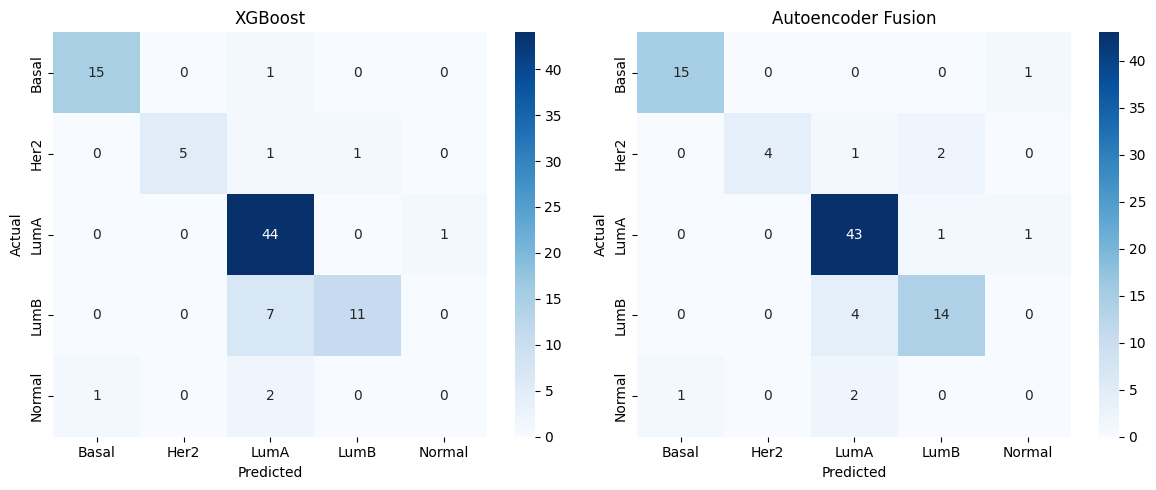

Confusion matrix figure saved.


In [4]:
# --- Confusion matrices side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_xgboost, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_classes, yticklabels=le_classes, ax=axes[0])
axes[0].set_title('XGBoost')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_autoencoder, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_classes, yticklabels=le_classes, ax=axes[1])
axes[1].set_title('Autoencoder Fusion')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../results/figures/confusion_matrices.png', dpi=150)
plt.show()

print("Confusion matrix figure saved.")

In [5]:
# --- Final comparison table ---
import pandas as pd
comparison = pd.DataFrame({
    'Model': ['XGBoost (baseline)', 'Autoencoder Fusion', 'Autoencoder - Expr only', 'Autoencoder - Mut only'],
    'Accuracy': [
        (xgb_model.predict(X_test) == y_test).mean(),
        meta['acc_full'],
        meta['acc_expr_only'],
        meta['acc_mut_only']
    ]
})
print(comparison)
comparison.to_csv('../results/figures/comparison_table.csv', index=False)

                     Model  Accuracy
0       XGBoost (baseline)  0.842697
1       Autoencoder Fusion  0.853933
2  Autoencoder - Expr only  0.853933
3   Autoencoder - Mut only  0.449438
